In [1]:
import pandas as pd
import numpy as np
df = pd.read_csv("continuallearningexperiments.csv").dropna()

PERF_COLS = ['test_abs_rel', 'test_sq_rel', 'test_log10', 'test_rmse', 'test_rmse_log', 'test_a1', 'test_a2', 'test_a3']

In [2]:
# compute stability
df_full = df[df['test_region_type'] == 'full'].drop(columns=['test_region_type'])
df_after = df_full[df_full['adaptation_state'] == 'after_adaptation'].drop(columns=['adaptation_state'])
group_columns = ['source_train_dataset', 'target_train_dataset', 'training_method']
df_stability = df_after[df_after['target_train_dataset'] != df_after['test_dataset']]
df_stability.sort_values(by=['source_train_dataset','test_abs_rel'])

,source_train_dataset,target_train_dataset,training_method,test_dataset,test_abs_rel,test_sq_rel,test_log10,test_rmse,test_rmse_log,test_a1,test_a2,test_a3
141,DDAD,KITTI,FedSCDepth(Average),DDAD,0.211,4.801,0.105,21.108,0.360,0.649,0.849,0.917
57,DDAD,KITTI,FedSCDepth,DDAD,0.214,4.996,0.107,21.585,0.367,0.646,0.842,0.913
129,DDAD,KITTI,FedSCDepth(Retrain),DDAD,0.216,4.896,0.108,21.308,0.366,0.636,0.846,0.915
153,DDAD,KITTI,FedSCDepth(Average&Retrain),DDAD,0.216,5.467,0.111,22.839,0.386,0.641,0.832,0.901
165,DDAD,KITTI,BOFedSCDepth(Retrain),DDAD,0.217,4.999,0.108,21.482,0.370,0.638,0.842,0.912
213,DDAD,KITTI,BOFedSCDepth(ConstrainedLossRetrain),DDAD,0.217,4.933,0.108,21.423,0.367,0.638,0.841,0.914
69,DDAD,KITTI,BOFedSCDepth,DDAD,0.227,5.246,0.113,22.061,0.382,0.612,0.830,0.906
201,DDAD,KITTI,BOFedSCDepth(ConstrainedLoss),DDAD,0.231,5.546,0.117,22.729,0.397,0.606,0.825,0.898
45,DDAD,KITTI,SCDepth,DDAD,0.240,5.242,0.118,21.523,0.392,0.590,0.822,0.904
78,KITTI,DDAD,FedSCDepth(Retrain),KITTI,0.170,1.204,0.069,5.266,0.226,0.772,0.937,0.981


In [3]:
# compute plasticity
df_before = df_full[df_full['adaptation_state'] == 'before_adaptation'].drop(columns=['adaptation_state'])
df_before_plasticity = df_before[df_before['test_dataset'] == df_before['source_train_dataset']]
df_after_plasticity = df_after[df_after['test_dataset'] == df_after['target_train_dataset']]
df_plasticity = pd.concat([df_before_plasticity, df_after_plasticity])
group_columns = ['source_train_dataset', 'target_train_dataset', 'training_method']
avg_columns = ['test_abs_rel', 'test_sq_rel', 'test_log10', 'test_rmse', 'test_rmse_log', 'test_a1', 'test_a2', 'test_a3']
df_plasticity = df_plasticity.groupby(group_columns, as_index=False)[PERF_COLS].mean()
df_plasticity.sort_values(by=['source_train_dataset','test_abs_rel'])

,source_train_dataset,target_train_dataset,training_method,test_abs_rel,test_sq_rel,test_log10,test_rmse,test_rmse_log,test_a1,test_a2,test_a3
8,DDAD,KITTI,SCDepth,0.1335,1.9615,0.0595,10.1565,0.2175,0.8295,0.9420,0.9750
0,DDAD,KITTI,BOFedSCDepth,0.1645,3.0600,0.0820,13.6955,0.2825,0.7430,0.8950,0.9455
2,DDAD,KITTI,BOFedSCDepth(ConstrainedLossRetrain),0.1650,3.0810,0.0815,13.6620,0.2825,0.7425,0.8950,0.9455
3,DDAD,KITTI,BOFedSCDepth(Retrain),0.1660,3.0865,0.0820,13.6775,0.2830,0.7420,0.8950,0.9455
1,DDAD,KITTI,BOFedSCDepth(ConstrainedLoss),0.1670,3.0835,0.0825,13.7280,0.2840,0.7390,0.8945,0.9455
5,DDAD,KITTI,FedSCDepth(Average&Retrain),0.2410,4.7155,0.1405,15.4240,0.4645,0.6485,0.7895,0.8420
4,DDAD,KITTI,FedSCDepth,0.2415,4.7435,0.1400,15.3635,0.4640,0.6505,0.7900,0.8420
7,DDAD,KITTI,FedSCDepth(Retrain),0.2415,4.7300,0.1405,15.3760,0.4645,0.6495,0.7895,0.8420
6,DDAD,KITTI,FedSCDepth(Average),0.2425,4.7505,0.1405,15.4090,0.4645,0.6485,0.7895,0.8420
17,KITTI,DDAD,SCDepth,0.1285,1.8670,0.0565,9.8055,0.2110,0.8440,0.9450,0.9765


In [4]:
# compute stability plasticity tradeoff
df_stability_plasticity = pd.concat([df_stability, df_plasticity])
df_stability_plasticity.sort_values(by=['source_train_dataset', 'target_train_dataset', 'training_method'])

def compute_stability_plasticity_tradeoff(group):
    product_series = {col: np.prod(group[col]) for col in PERF_COLS}
    product_series_multiplied_by_two = {col: val * 2 for col, val in product_series.items()}
    sum_series = {col: np.sum(group[col]) for col in avg_columns}
    product_series_multiplied_by_two = pd.Series(product_series_multiplied_by_two)
    sum_series = pd.Series(sum_series)
    return product_series_multiplied_by_two / sum_series

df_stability_plasticity_tradeoff = df_stability_plasticity.groupby(['source_train_dataset','target_train_dataset','training_method'], as_index=False).apply(compute_stability_plasticity_tradeoff)
df_stability_plasticity_tradeoff.sort_values(by=['source_train_dataset','test_abs_rel'])

,source_train_dataset,target_train_dataset,training_method,test_abs_rel,test_sq_rel,test_log10,test_rmse,test_rmse_log,test_a1,test_a2,test_a3
8,DDAD,KITTI,SCDepth,0.171566,2.854774,0.079110,13.800619,0.279770,0.689546,0.877918,0.938159
2,DDAD,KITTI,BOFedSCDepth(ConstrainedLossRetrain),0.187461,3.793005,0.092897,16.684112,0.319253,0.686295,0.867160,0.929483
3,DDAD,KITTI,BOFedSCDepth(Retrain),0.188104,3.816564,0.093221,16.713551,0.320704,0.686081,0.867691,0.928448
0,DDAD,KITTI,BOFedSCDepth,0.190761,3.865341,0.095036,16.899664,0.324801,0.671168,0.861275,0.925329
1,DDAD,KITTI,BOFedSCDepth(ConstrainedLoss),0.193854,3.963403,0.096767,17.117355,0.331125,0.665924,0.858345,0.921138
6,DDAD,KITTI,FedSCDepth(Average),0.225656,4.775617,0.120183,17.813795,0.405628,0.648750,0.818170,0.877901
4,DDAD,KITTI,FedSCDepth,0.226920,4.866477,0.121296,17.950453,0.409839,0.648242,0.815172,0.876064
5,DDAD,KITTI,FedSCDepth(Average&Retrain),0.227816,5.063518,0.124020,18.413022,0.421627,0.644728,0.810193,0.870501
7,DDAD,KITTI,FedSCDepth(Retrain),0.228039,4.811569,0.122125,17.862382,0.409409,0.642679,0.816774,0.876983
16,KITTI,DDAD,FedSCDepth(Retrain),0.157953,1.595890,0.068749,7.325762,0.234886,0.784543,0.930455,0.971917


In [48]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.preprocessing import MinMaxScaler
import seaborn as sns
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D

# Set display options and plot styles
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
plt.rcParams["font.weight"] = "bold"
plt.rcParams["axes.labelweight"] = "bold"
font = {'weight': 'bold', 'size': 30}
plt.rc('font', **font)

# Define color palette and hatch patterns
colors = sns.color_palette("colorblind")  # Colorblind-friendly colors
hatches = ['/', '\\', '|', '-', '+', 'x', 'o', 'O', '.', '*']  # Hatching patterns

def normalize_metrics(df, target_metrics, inverse=False):
    """
    Normalize the specified metrics globally using MinMaxScaler.
    """
    scaler = MinMaxScaler()
    display(df)
    if inverse:
        df[target_metrics] = 1 - scaler.fit_transform(df[target_metrics])
    else:
        df[target_metrics] = scaler.fit_transform(df[target_metrics])
    display(df)
    return df

def generate_radar_charts(df, target_metrics, label, target_methods=None, normalize=False, inverse=False):
    # Filter by target methods if specified
    if target_methods:
        df = pd.concat([df[df['training_method'] == target_method] for target_method in target_methods])

    # Rename training methods for clarity
    replace_dict = {
        'FedSCDepth(Average)': 'CFSCD',
        'FedSCDepth(Retrain)': 'ERFSCD',
        'FedSCDepth(Average&Retrain)': 'CERFSCD',
        'FedSCDepth': 'FSCD',
        'BOFedSCDepth(Average)': 'CBOFSCD',
        'BOFedSCDepth(Retrain)': 'ERBOFSCD',
        'BOFedSCDepth(ConstrainedLoss)': 'LBOFSCD',
        'BOFedSCDepth(ConstrainedLossRetrain)': 'LERBOFSCD',
        'BOFedSCDepth(Average&Retrain)': 'CERBOFSCD',
        'BOFedSCDepth': 'BOFSCD'
    }
    df = df.replace({'training_method': replace_dict})

    # Normalize metrics globally
    if normalize:
        df = normalize_metrics(df, target_metrics, inverse)

    # Create readable labels for metrics
    label_metric = lambda metric: metric.replace('test_', "").replace("_comparison", "").replace("_", " ").upper()
    label_by_target_metric = {metric: label_metric(metric) for metric in target_metrics}
    df = df.rename(columns=label_by_target_metric)
    target_metrics = list(label_by_target_metric.values())

    # Group data by source and target datasets
    combinations = df.groupby(['source_train_dataset', 'target_train_dataset'])

    # Function to create radar charts
    def create_radar_chart(categories, values, labels, title, filename):
        num_vars = len(categories)
        angles = np.linspace(0, 2 * np.pi, num_vars, endpoint=False).tolist()
        values = [v + [v[0]] for v in values]  # Close the loop
        angles += angles[:1]  # Duplicate first angle for full circle

        fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))

        for i, (value, label) in enumerate(zip(values, labels)):
            ax.plot(angles, value, label=label, linewidth=2, color=colors[i % len(colors)], linestyle='-', marker='o')
            ax.fill(angles, value, alpha=0.25, color=colors[i % len(colors)], hatch=hatches[i % len(hatches)])

        ax.set_yticks([])
        ax.set_xticks(angles[:-1])
        ax.set_xticklabels(categories, fontsize=12)

        handles = []
        added_labels = set()
        for i, label in enumerate(labels):
            if label not in added_labels:
                patch = mpatches.Patch(color=colors[i % len(colors)], label=label, hatch=hatches[i % len(hatches)], lw=2)
                handles.append(patch)
                added_labels.add(label)

        ax.set_title(title, fontsize=16)
        ax.legend(handles=handles, loc='upper center', bbox_to_anchor=(0.5, -0.1), ncol=4, fontsize=10)

        plt.tight_layout(rect=[0, 0, 1, 0.9])
        plt.savefig(filename)
        print(f"Saved radar chart: {filename}")
        plt.show()

    # Iterate through combinations of source and target datasets
    for (source, target), group in combinations:
        categories = target_metrics
        values = []
        labels = []

        for method in group['training_method'].unique():
            subset = group[group['training_method'] == method]
            avg_values = [subset[metric].mean() for metric in target_metrics]
            values.append(avg_values)
            labels.append(method)

        title = f'{label} Metrics Radar Chart for {source} -> {target}'
        filename = f"{label.lower()}_radar_chart_{source}_to_{target}.pdf"

        create_radar_chart(categories, values, labels, title, filename)


In [6]:
target_methods = ['FedSCDepth','FedSCDepth(Retrain)','FedSCDepth(Average)','FedSCDepth(Average&Retrain)']

,source_train_dataset,target_train_dataset,training_method,test_abs_rel,test_sq_rel,test_log10,test_rmse,test_rmse_log,test_a1,test_a2,test_a3
4,DDAD,KITTI,FSCD,0.226920,4.866477,0.121296,17.950453,0.409839,0.648242,0.815172,0.876064
13,KITTI,DDAD,FSCD,0.169311,2.165941,0.071952,8.661217,0.246970,0.759170,0.918238,0.967248
7,DDAD,KITTI,ERFSCD,0.228039,4.811569,0.122125,17.862382,0.409409,0.642679,0.816774,0.876983
16,KITTI,DDAD,ERFSCD,0.157953,1.595890,0.068749,7.325762,0.234886,0.784543,0.930455,0.971917
6,DDAD,KITTI,CFSCD,0.225656,4.775617,0.120183,17.813795,0.405628,0.648750,0.818170,0.877901
15,KITTI,DDAD,CFSCD,0.171437,2.288077,0.072391,9.009516,0.248402,0.754778,0.914947,0.965727
5,DDAD,KITTI,CERFSCD,0.227816,5.063518,0.124020,18.413022,0.421627,0.644728,0.810193,0.870501
14,KITTI,DDAD,CERFSCD,0.165049,1.932615,0.069901,8.042029,0.238310,0.774365,0.927685,0.971498


,source_train_dataset,target_train_dataset,training_method,test_abs_rel,test_sq_rel,test_log10,test_rmse,test_rmse_log,test_a1,test_a2,test_a3
4,DDAD,KITTI,FSCD,0.015973,0.056823,0.049291,0.041721,0.063128,0.648242,0.815172,0.876064
13,KITTI,DDAD,FSCD,0.837941,0.835608,0.942047,0.879550,0.935293,0.759170,0.918238,0.967248
7,DDAD,KITTI,ERFSCD,0.000000,0.072658,0.034288,0.049664,0.065430,0.642679,0.816774,0.876983
16,KITTI,DDAD,ERFSCD,1.000000,1.000000,1.000000,1.000000,1.000000,0.784543,0.930455,0.971917
6,DDAD,KITTI,CFSCD,0.034006,0.083026,0.069414,0.054046,0.085678,0.648750,0.818170,0.877901
15,KITTI,DDAD,CFSCD,0.807604,0.800386,0.934116,0.848136,0.927623,0.754778,0.914947,0.965727
5,DDAD,KITTI,CERFSCD,0.003184,0.000000,0.000000,0.000000,0.000000,0.644728,0.810193,0.870501
14,KITTI,DDAD,CERFSCD,0.898756,0.902895,0.979164,0.935397,0.981666,0.774365,0.927685,0.971498


Saved radar chart: loss_radar_chart_DDAD_to_KITTI.pdf


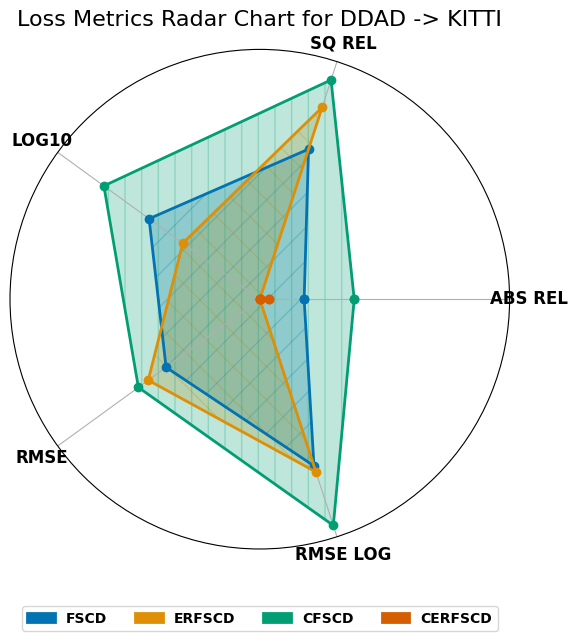

Saved radar chart: loss_radar_chart_KITTI_to_DDAD.pdf


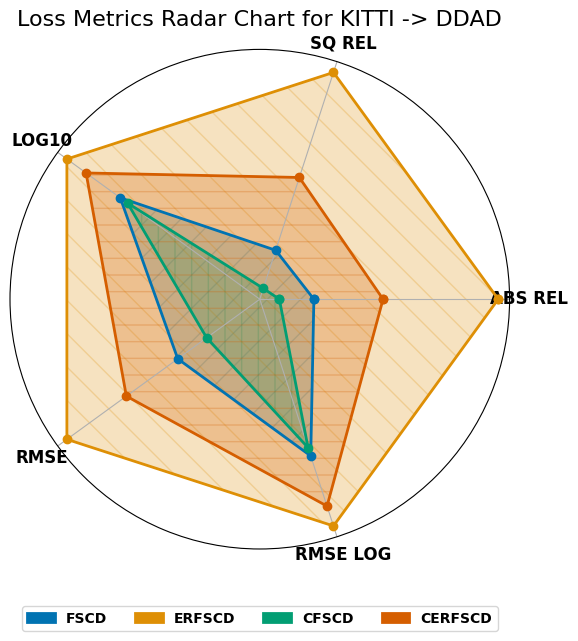

In [49]:
loss_metrics = ['test_abs_rel', 'test_sq_rel', 'test_log10', 'test_rmse', 'test_rmse_log']
generate_radar_charts(df_stability_plasticity_tradeoff, loss_metrics, 'Loss', target_methods, True, True)

,source_train_dataset,target_train_dataset,training_method,test_abs_rel,test_sq_rel,test_log10,test_rmse,test_rmse_log,test_a1,test_a2,test_a3
4,DDAD,KITTI,FSCD,0.226920,4.866477,0.121296,17.950453,0.409839,0.648242,0.815172,0.876064
13,KITTI,DDAD,FSCD,0.169311,2.165941,0.071952,8.661217,0.246970,0.759170,0.918238,0.967248
7,DDAD,KITTI,ERFSCD,0.228039,4.811569,0.122125,17.862382,0.409409,0.642679,0.816774,0.876983
16,KITTI,DDAD,ERFSCD,0.157953,1.595890,0.068749,7.325762,0.234886,0.784543,0.930455,0.971917
6,DDAD,KITTI,CFSCD,0.225656,4.775617,0.120183,17.813795,0.405628,0.648750,0.818170,0.877901
15,KITTI,DDAD,CFSCD,0.171437,2.288077,0.072391,9.009516,0.248402,0.754778,0.914947,0.965727
5,DDAD,KITTI,CERFSCD,0.227816,5.063518,0.124020,18.413022,0.421627,0.644728,0.810193,0.870501
14,KITTI,DDAD,CERFSCD,0.165049,1.932615,0.069901,8.042029,0.238310,0.774365,0.927685,0.971498


,source_train_dataset,target_train_dataset,training_method,test_abs_rel,test_sq_rel,test_log10,test_rmse,test_rmse_log,test_a1,test_a2,test_a3
4,DDAD,KITTI,FSCD,0.226920,4.866477,0.121296,17.950453,0.409839,0.039214,0.041398,0.054848
13,KITTI,DDAD,FSCD,0.169311,2.165941,0.071952,8.661217,0.246970,0.821144,0.898420,0.953969
7,DDAD,KITTI,ERFSCD,0.228039,4.811569,0.122125,17.862382,0.409409,0.000000,0.054723,0.063916
16,KITTI,DDAD,ERFSCD,0.157953,1.595890,0.068749,7.325762,0.234886,1.000000,1.000000,1.000000
6,DDAD,KITTI,CFSCD,0.225656,4.775617,0.120183,17.813795,0.405628,0.042793,0.066327,0.072964
15,KITTI,DDAD,CFSCD,0.171437,2.288077,0.072391,9.009516,0.248402,0.790184,0.871051,0.938964
5,DDAD,KITTI,CERFSCD,0.227816,5.063518,0.124020,18.413022,0.421627,0.014444,0.000000,0.000000
14,KITTI,DDAD,CERFSCD,0.165049,1.932615,0.069901,8.042029,0.238310,0.928258,0.976972,0.995869


Saved radar chart: accuracy_radar_chart_DDAD_to_KITTI.pdf


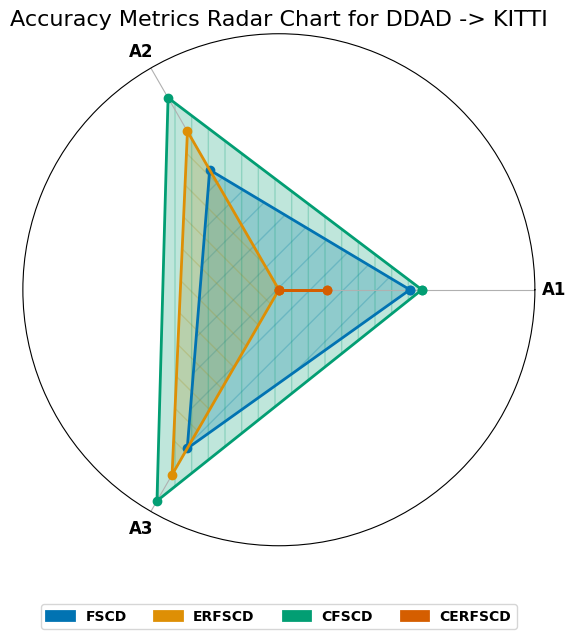

Saved radar chart: accuracy_radar_chart_KITTI_to_DDAD.pdf


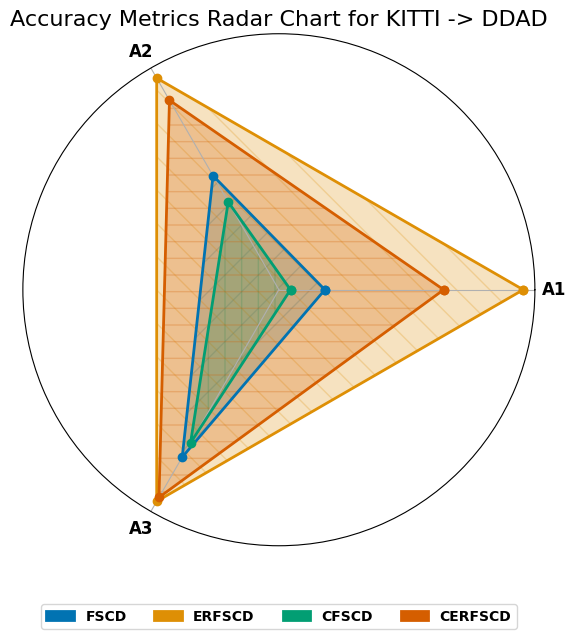

In [51]:
accuracy_metrics = ['test_a1', 'test_a2', 'test_a3']
generate_radar_charts(df_stability_plasticity_tradeoff, accuracy_metrics, 'Accuracy', target_methods, True)